## Week 10 Homework：ARIA v7.0 — The All-Weather Auditor

依照 `Homework-Week10.md` 完成四個任務：**SAR 淹水萃取（SAR Flood Extraction）**、**感測器融合（Sensor Fusion）**、**地形審計（Topographic Audit）**、以及 **AI Strategic Briefing**。整體邏輯是先用 Sentinel-1 SAR 在雲多時偵測可能淹水區，再把 W9 的 NDWI 水體遮罩與 SCL 雲遮罩合併成四分類信心圖，最後用坡度檢查陡坡上的假水體。

**Captain's Log：** 這份作業的重點不是只把圖跑出來，而是要檢查結果是否合理。SAR 在雲層下很有用，但也容易受到 **speckle noise（斑點雜訊）** 與 **terrain distortion（地形變形）** 影響，所以每一步都需要用面積、圖面與物理直覺交叉確認。

In [1]:
# [0] Environment & reproducible parameters
import os, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject
from scipy.ndimage import median_filter, binary_opening, label

try:
    from dotenv import load_dotenv
    load_dotenv()
except Exception:
    pass

plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei", "PingFang TC", "Noto Sans CJK TC", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

DATA_DIR = Path(os.getenv("DATA_DIR", "data"))
OUTPUT_DIR = Path(os.getenv("OUTPUT_DIR", "output"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAR_FILE = Path(os.getenv("SAR_FILE", "../data/S1_Hualien_dB.tif"))
NDWI_MASK_FILE = Path(os.getenv("NDWI_MASK_FILE", "../class9/output/ndwi_water_mask.npy"))
SCL_CLOUD_MASK_FILE = Path(os.getenv("SCL_CLOUD_MASK_FILE", "../class9/output/scl_cloud_mask.npy"))
SLOPE_FILE = Path(os.getenv("SLOPE_FILE", "../class4/output/slope_degrees.tif"))

SAR_THRESHOLD = float(os.getenv("SAR_THRESHOLD", -18))
NDWI_THRESHOLD = float(os.getenv("NDWI_THRESHOLD", 0.3))
SLOPE_THRESHOLD = float(os.getenv("SLOPE_THRESHOLD", 25))
MIN_WATER_PIXELS = int(os.getenv("MIN_WATER_PIXELS", 50))
MEDIAN_KERNEL = int(os.getenv("MEDIAN_KERNEL", 5))

print("✅ Environment ready")
print(f"SAR_FILE={SAR_FILE}, SAR_THRESHOLD={SAR_THRESHOLD} dB, NDWI_THRESHOLD={NDWI_THRESHOLD}, SLOPE_THRESHOLD={SLOPE_THRESHOLD}°")

✅ Environment ready
SAR_FILE=..\data\S1_Hualien_dB.tif, SAR_THRESHOLD=-18.0 dB, NDWI_THRESHOLD=0.3, SLOPE_THRESHOLD=25.0°


## Task 1：SAR All-Weather Flood Detection

這一段讀取已預處理的 Sentinel-1 SAR GeoTIFF。`S1_Hualien_dB.tif` 應該已經是 **VV polarization（VV 極化）**、完成 calibration（輻射校正）與 terrain correction（地形校正）的 dB 影像，所以不需要再做 `10 × log10()` 轉換。水面通常因為 **specular reflection（鏡面反射）** 讓回波變低，在 SAR 影像中會偏暗。

In [2]:
# [1] Helper functions
def resolve_path(path, fallback_dirs=(Path("."), DATA_DIR, Path("/mnt/data"))):
    """Find a file from current path, data folder, or uploaded-file folder."""
    path = Path(path)
    candidates = [path] if path.is_absolute() else []
    candidates += [d / path for d in fallback_dirs]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"找不到檔案：{path}，請確認它在目前資料夾、data/ 或 /mnt/data。")

def read_single_band_tif(path):
    """Read first band of GeoTIFF and return array plus profile."""
    path = resolve_path(path)
    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32)
        profile = src.profile.copy()
        nodata = src.nodata
    if nodata is not None:
        arr = np.where(arr == nodata, np.nan, arr)
    return arr, profile, path

def pixel_area_km2_from_profile(profile):
    """Compute pixel area in square kilometers from GeoTIFF transform."""
    transform = profile["transform"]
    return abs(transform.a * transform.e) / 1_000_000

def load_mask_any(path, target_shape=None, dtype=np.uint8):
    """Load a mask from .npy or GeoTIFF."""
    path = resolve_path(path)
    if path.suffix.lower() == ".npy":
        arr = np.load(path)
    else:
        arr, _, _ = read_single_band_tif(path)
    arr = arr.astype(dtype)
    if target_shape is not None and arr.shape != target_shape:
        raise ValueError(f"{path} shape {arr.shape} 與目標 shape {target_shape} 不一致，請先重投影或重取樣。")
    return arr, path

def reproject_to_match(src_arr, src_profile, dst_profile, resampling=Resampling.nearest):
    """Reproject source raster array to destination raster grid."""
    dst_arr = np.zeros((dst_profile["height"], dst_profile["width"]), dtype=src_arr.dtype)
    reproject(source=src_arr, destination=dst_arr,
              src_transform=src_profile["transform"], src_crs=src_profile["crs"],
              dst_transform=dst_profile["transform"], dst_crs=dst_profile["crs"],
              resampling=resampling)
    return dst_arr

def save_geotiff(path, arr, reference_profile, dtype=None, nodata=None):
    """Save array as GeoTIFF using a reference raster profile."""
    profile = reference_profile.copy()
    profile.update(count=1, dtype=dtype or arr.dtype, compress="lzw", nodata=nodata)
    with rasterio.open(path, "w", **profile) as dst:
        dst.write(arr.astype(dtype or arr.dtype), 1)
    return Path(path)

def area_table_from_classes(class_arr, class_labels, pixel_area_km2):
    """Create area statistics table for classified raster."""
    rows=[]
    for value, name in class_labels.items():
        n=int(np.sum(class_arr==value))
        rows.append({"class_code":value,"class_name":name,"pixels":n,"area_km2":n*pixel_area_km2})
    return pd.DataFrame(rows)

print("✅ Helper functions ready")

✅ Helper functions ready


In [3]:
# [2] Load and inspect SAR GeoTIFF
sar_db, sar_profile, sar_path = read_single_band_tif(SAR_FILE)
pixel_area_km2 = pixel_area_km2_from_profile(sar_profile)

print(f"✅ SAR loaded: {sar_path}")
print(f"Shape: {sar_db.shape}")
print(f"CRS: {sar_profile['crs']}")
print(f"Pixel area: {pixel_area_km2:.6f} km²")
print(f"SAR dB range: {np.nanmin(sar_db):.2f} to {np.nanmax(sar_db):.2f} dB")

if np.nanmin(sar_db) < -60 or np.nanmax(sar_db) > 20:
    print("⚠️ 數值範圍看起來不像一般 dB SAR，請確認檔案是否已轉成 dB。")

✅ SAR loaded: data\..\data\S1_Hualien_dB.tif
Shape: (2242, 2473)
CRS: EPSG:32651
Pixel area: 0.000100 km²
SAR dB range: -28.71 to 26.72 dB
⚠️ 數值範圍看起來不像一般 dB SAR，請確認檔案是否已轉成 dB。


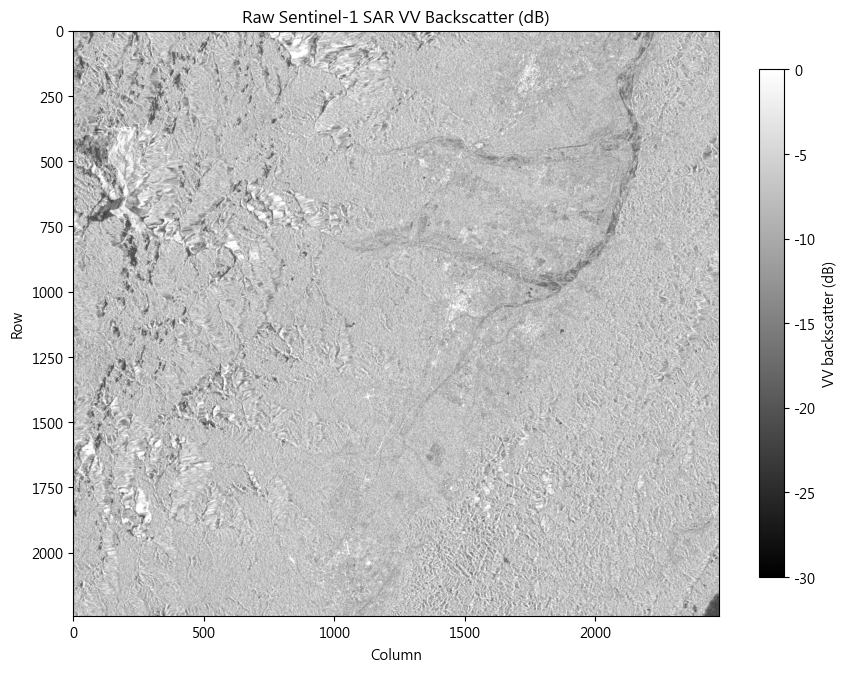

In [4]:
# [3] Visualize raw SAR image
fig, ax = plt.subplots(figsize=(9,7))
im = ax.imshow(sar_db, cmap="gray", vmin=-30, vmax=0)
ax.set_title("Raw Sentinel-1 SAR VV Backscatter (dB)")
ax.set_xlabel("Column"); ax.set_ylabel("Row")
plt.colorbar(im, ax=ax, label="VV backscatter (dB)", shrink=0.8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "task1_raw_sar.png", dpi=150, bbox_inches="tight")
plt.show()

**Captain's Log：** 原始 SAR 影像可以先用來檢查場景是否合理，但不能直接做 threshold。因為 SAR 有 **speckle noise（斑點雜訊）**，如果直接把所有低於門檻的像素都當成水，會得到很多零碎假水體。

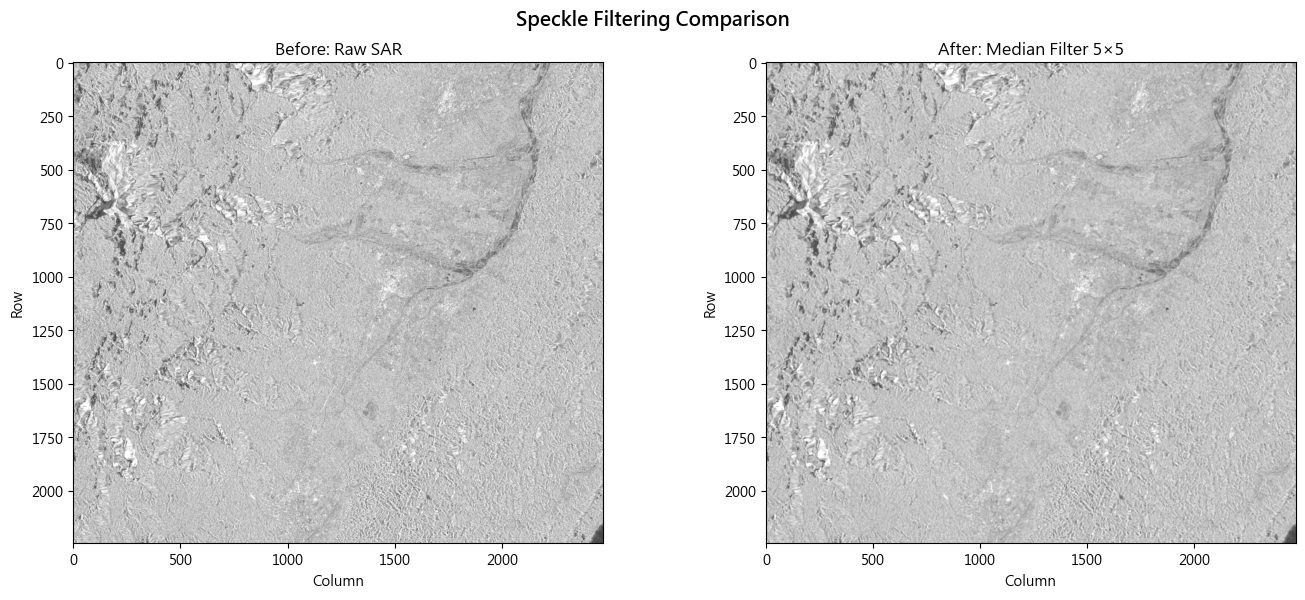

In [5]:
# [4] Speckle filtering with median filter
sar_filtered = median_filter(sar_db, size=MEDIAN_KERNEL)

fig, axes = plt.subplots(1,2,figsize=(14,6))
axes[0].imshow(sar_db, cmap="gray", vmin=-30, vmax=0)
axes[0].set_title("Before: Raw SAR")
axes[1].imshow(sar_filtered, cmap="gray", vmin=-30, vmax=0)
axes[1].set_title(f"After: Median Filter {MEDIAN_KERNEL}×{MEDIAN_KERNEL}")
for ax in axes:
    ax.set_xlabel("Column"); ax.set_ylabel("Row")
plt.suptitle("Speckle Filtering Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "task1_speckle_filter_before_after.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# [5] Threshold segmentation + morphological cleanup
sar_water_raw = (sar_filtered < SAR_THRESHOLD).astype(np.uint8)

structure = np.ones((3,3), dtype=np.uint8)
sar_water_opened = binary_opening(sar_water_raw, structure=structure, iterations=1).astype(np.uint8)

labeled, n_features = label(sar_water_opened)
sar_water = np.zeros_like(sar_water_opened, dtype=np.uint8)
kept_regions, removed_small_regions = 0, 0
for region_id in range(1, n_features+1):
    region_size = int(np.sum(labeled == region_id))
    if region_size >= MIN_WATER_PIXELS:
        sar_water[labeled == region_id] = 1
        kept_regions += 1
    else:
        removed_small_regions += 1

water_pixels = int(np.sum(sar_water))
flood_area_km2 = water_pixels * pixel_area_km2
mean_backscatter = float(np.nanmean(sar_filtered[sar_water == 1])) if water_pixels > 0 else np.nan

print(f"Raw threshold pixels: {int(np.sum(sar_water_raw)):,}")
print(f"After opening pixels: {int(np.sum(sar_water_opened)):,}")
print(f"Final water pixels: {water_pixels:,}")
print(f"Kept connected regions: {kept_regions:,}; removed small regions: {removed_small_regions:,}")
print(f"Flooded area: {flood_area_km2:.3f} km²")
print(f"Mean backscatter in flood zone: {mean_backscatter:.2f} dB")

save_geotiff(OUTPUT_DIR / "sar_water_mask.tif", sar_water, sar_profile, dtype="uint8", nodata=0)
np.save(OUTPUT_DIR / "sar_water_mask.npy", sar_water)

Raw threshold pixels: 28,145
After opening pixels: 25,319
Final water pixels: 20,207
Kept connected regions: 114; removed small regions: 222
Flooded area: 2.021 km²
Mean backscatter in flood zone: -19.62 dB


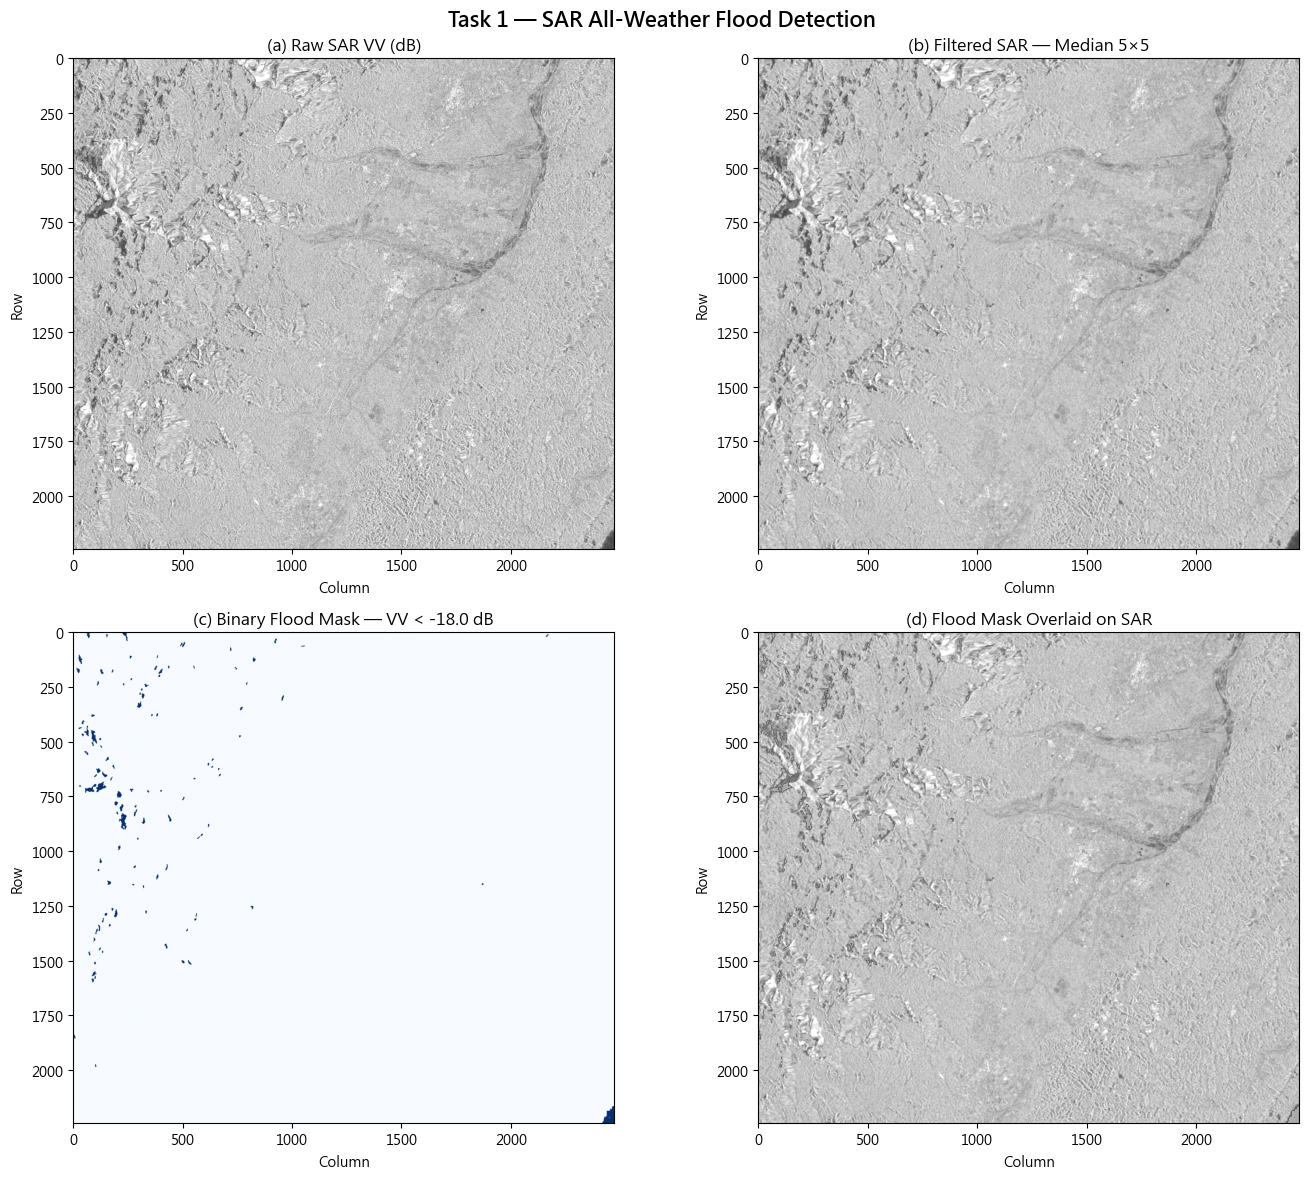

,SAR threshold (dB),water pixels,flooded area (km²),mean backscatter in flood zone (dB),median filter,minimum component size (px)
0,-18.0,20207,2.0207,-19.61581,5×5,50


SAR detected 2.021 km² of flooding that optical sensors may not see under cloud cover.


In [7]:
# [6] Task 1 deliverable: 2×2 subplot + area table
fig, axes = plt.subplots(2,2,figsize=(14,12))
axes[0,0].imshow(sar_db, cmap="gray", vmin=-30, vmax=0)
axes[0,0].set_title("(a) Raw SAR VV (dB)")
axes[0,1].imshow(sar_filtered, cmap="gray", vmin=-30, vmax=0)
axes[0,1].set_title(f"(b) Filtered SAR — Median {MEDIAN_KERNEL}×{MEDIAN_KERNEL}")
axes[1,0].imshow(sar_water, cmap="Blues", vmin=0, vmax=1)
axes[1,0].set_title(f"(c) Binary Flood Mask — VV < {SAR_THRESHOLD} dB")
axes[1,1].imshow(sar_filtered, cmap="gray", vmin=-30, vmax=0)
axes[1,1].imshow(np.ma.masked_where(sar_water==0, sar_water), cmap="Blues", alpha=0.55)
axes[1,1].set_title("(d) Flood Mask Overlaid on SAR")
for ax in axes.flat:
    ax.set_xlabel("Column"); ax.set_ylabel("Row")
plt.suptitle("Task 1 — SAR All-Weather Flood Detection", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "task1_sar_flood_detection_2x2.png", dpi=150, bbox_inches="tight")
plt.show()

task1_table = pd.DataFrame([{
    "SAR threshold (dB)": SAR_THRESHOLD,
    "water pixels": water_pixels,
    "flooded area (km²)": flood_area_km2,
    "mean backscatter in flood zone (dB)": mean_backscatter,
    "median filter": f"{MEDIAN_KERNEL}×{MEDIAN_KERNEL}",
    "minimum component size (px)": MIN_WATER_PIXELS,
}])
display(task1_table)
task1_table.to_csv(OUTPUT_DIR / "task1_sar_area_table.csv", index=False)
print(f"SAR detected {flood_area_km2:.3f} km² of flooding that optical sensors may not see under cloud cover.")

## Task 2：Sensor Fusion — Multi-Source Confidence Map

這一段把 W9 的 **NDWI water mask（光學水體遮罩）** 與 **SCL cloud mask（雲遮罩）** 加進來。融合邏輯不是把兩張圖硬加起來，而是把不同資料來源的證據強度分級：SAR 與 NDWI 都偵測到水就是 **High Confidence（高信心）**；雲底下只有 SAR 偵測到水就是 **SAR Only (Cloudy)**；無雲情境下只有 NDWI 偵測到水就是 **Optical Only**，需要人工檢查。

❗出現投影問題
NDWI / SCL mask 與 SAR raster 差 1 pixel：

NDWI / SCL: (2243, 2474)

SAR:        (2242, 2473)

shape (2243, 2474) 與目標 shape (2242, 2473) 不一致，請先重投影或重取樣。

In [9]:
import rasterio
from rasterio.warp import reproject
from rasterio.enums import Resampling
import numpy as np

def reproject_to_match(src_array, src_profile, dst_profile, resampling=Resampling.nearest):
    dst_array = np.zeros(
        (dst_profile["height"], dst_profile["width"]),
        dtype=src_array.dtype
    )

    reproject(
        source=src_array,
        destination=dst_array,
        src_transform=src_profile["transform"],
        src_crs=src_profile["crs"],
        dst_transform=dst_profile["transform"],
        dst_crs=dst_profile["crs"],
        resampling=resampling
    )

    return dst_array

In [12]:
# [7] Load W9 NDWI water mask and SCL cloud mask, reproject to SAR grid if needed
from rasterio.enums import Resampling
import numpy as np

H, W = sar_water.shape

def load_mask_to_sar_grid(mask_file, sar_profile, mask_name="mask"):
    """
    Load a single-band mask and reproject/resample it to SAR grid.
    Output is binary uint8 mask with shape equal to sar_water.
    """
    mask, mask_profile, mask_path = read_single_band_tif(mask_file)
    print(f"✅ {mask_name} loaded: {mask_path}")
    print(f"{mask_name} original shape: {mask.shape}")

    if mask.shape != (sar_profile["height"], sar_profile["width"]):
        print(
            f"{mask_name} shape {mask.shape} differs from SAR shape "
            f"({sar_profile['height']}, {sar_profile['width']}); reprojecting to SAR grid."
        )

        mask = reproject_to_match(
            mask.astype(np.uint8),
            mask_profile,
            sar_profile,
            resampling=Resampling.nearest
        )

    mask = (mask > 0).astype(np.uint8)
    print(f"{mask_name} final shape: {mask.shape}")

    return mask, mask_path


try:
    ndwi_mask, ndwi_path = load_mask_to_sar_grid(
        NDWI_MASK_FILE,
        sar_profile,
        mask_name="NDWI mask"
    )

except Exception as e:
    print(f"⚠️ 無法載入或重投影 NDWI mask：{e}")
    print("建立 placeholder：全部設為 0。正式繳交前請確認 NDWI_MASK_FILE 與 CRS/transform。")
    ndwi_mask = np.zeros((H, W), dtype=np.uint8)


try:
    cloud_mask, cloud_path = load_mask_to_sar_grid(
        SCL_CLOUD_MASK_FILE,
        sar_profile,
        mask_name="SCL cloud mask"
    )

except Exception as e:
    print(f"⚠️ 無法載入或重投影 SCL cloud mask：{e}")
    print("建立 placeholder：假設全區雲遮蔽。正式繳交前請確認 SCL_CLOUD_MASK_FILE 與 CRS/transform。")
    cloud_mask = np.ones((H, W), dtype=np.uint8)


assert sar_water.shape == ndwi_mask.shape == cloud_mask.shape

cloud_cover_pct = float(np.mean(cloud_mask) * 100)

print(f"Cloud cover percentage: {cloud_cover_pct:.1f}%")
print(f"NDWI water pixels: {int(np.sum(ndwi_mask)):,}")
print(f"SAR water pixels: {int(np.sum(sar_water)):,}")

✅ NDWI mask loaded: C:\Users\vicky\Desktop\NTU\GA 遙測與空間資訊之分析與應用\windsurf-project\week9_change_detection\Homework\output\ndwi_water_mask.tif
NDWI mask original shape: (2243, 2474)
NDWI mask shape (2243, 2474) differs from SAR shape (2242, 2473); reprojecting to SAR grid.
NDWI mask final shape: (2242, 2473)
✅ SCL cloud mask loaded: C:\Users\vicky\Desktop\NTU\GA 遙測與空間資訊之分析與應用\windsurf-project\week9_change_detection\Homework\output\scl_cloud_mask.tif
SCL cloud mask original shape: (2243, 2474)
SCL cloud mask shape (2243, 2474) differs from SAR shape (2242, 2473); reprojecting to SAR grid.
SCL cloud mask final shape: (2242, 2473)
Cloud cover percentage: 28.4%
NDWI water pixels: 248,166
SAR water pixels: 20,207


In [13]:
# [8] Apply 4-class fusion logic
fusion = np.zeros((H,W), dtype=np.uint8)
fusion[(ndwi_mask == 1) & (sar_water == 1) & (cloud_mask == 0)] = 3
fusion[(cloud_mask == 1) & (sar_water == 1)] = 2
fusion[(ndwi_mask == 1) & (sar_water == 0) & (cloud_mask == 0)] = 1

fusion_labels = {
    0: "No Detection",
    1: "Optical Only — needs review",
    2: "SAR Only (Cloudy) — radar evidence",
    3: "High Confidence — dual evidence",
}
fusion_table = area_table_from_classes(fusion, fusion_labels, pixel_area_km2)
display(fusion_table)
fusion_table.to_csv(OUTPUT_DIR / "task2_fusion_area_table.csv", index=False)
save_geotiff(OUTPUT_DIR / "fusion_confidence_map.tif", fusion, sar_profile, dtype="uint8", nodata=0)
np.save(OUTPUT_DIR / "fusion_confidence_map.npy", fusion)

,class_code,class_name,pixels,area_km2
0,0,No Detection,5319238,531.9238
1,1,Optical Only — needs review,212188,21.2188
2,2,SAR Only (Cloudy) — radar evidence,11188,1.1188
3,3,High Confidence — dual evidence,1852,0.1852


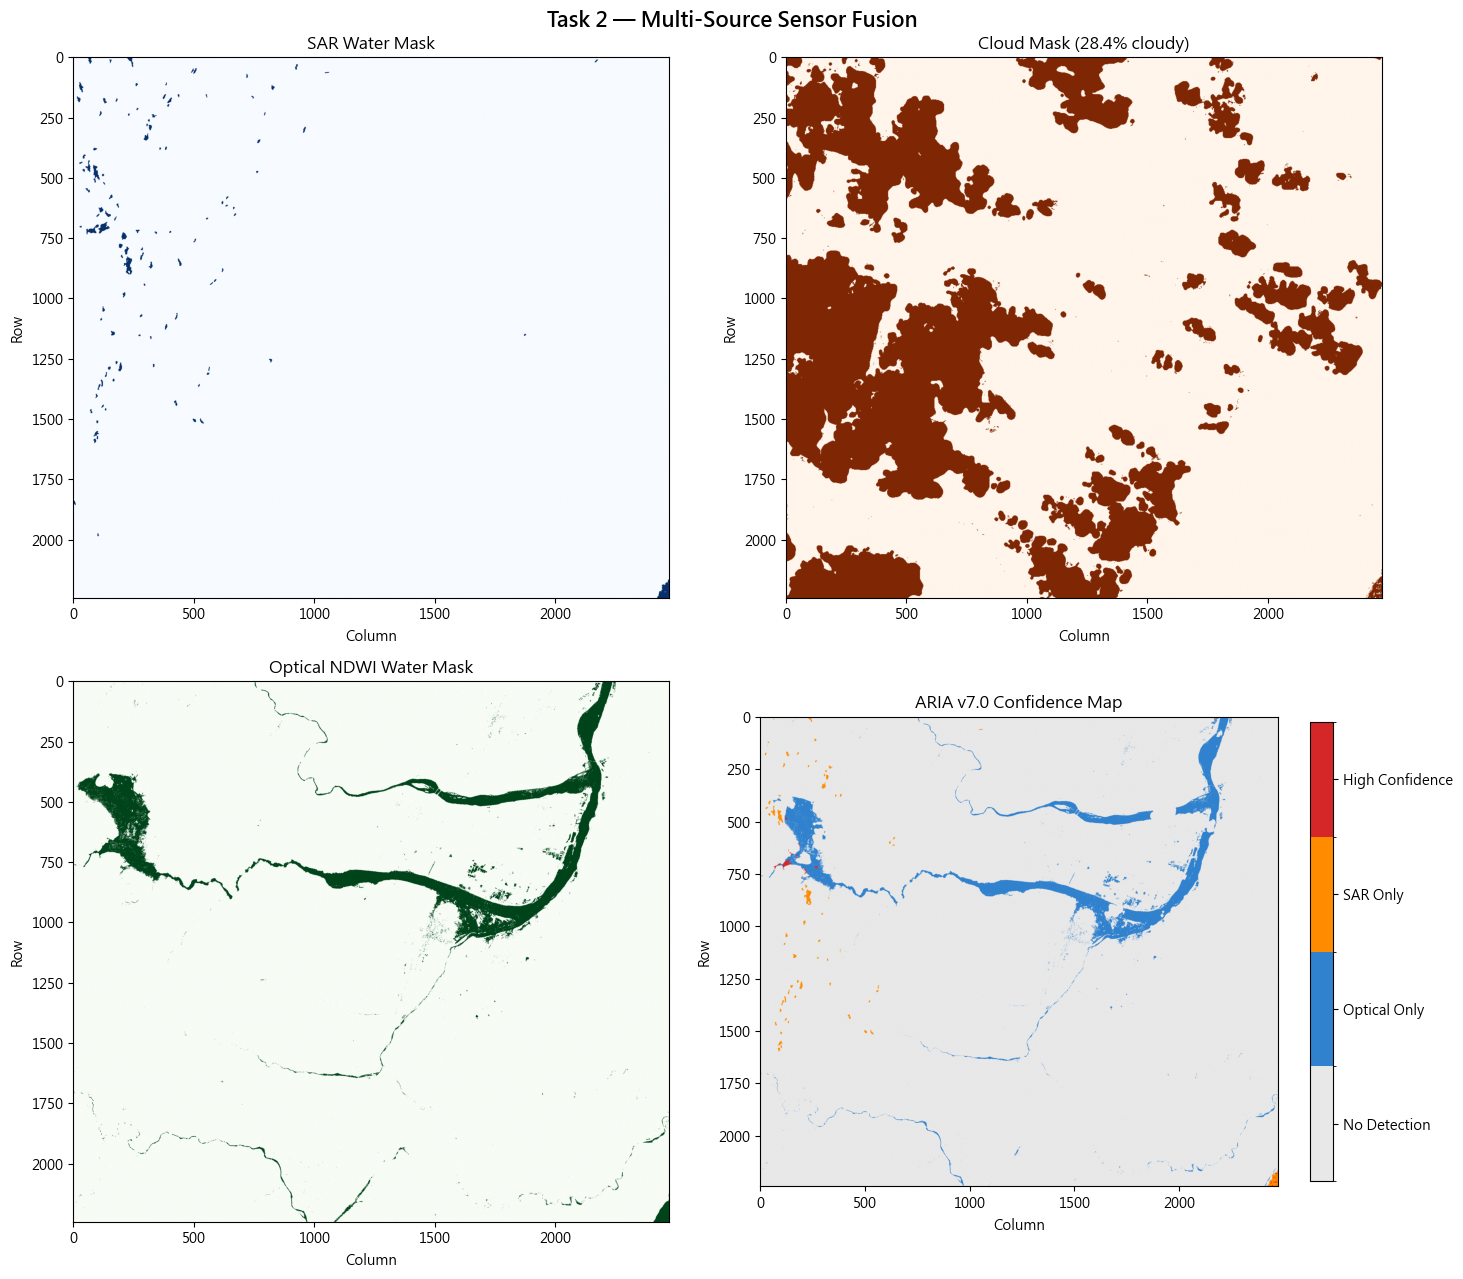

High confidence zones cover 0.185 km², representing areas confirmed by both sensors.
SAR-only zones add 1.119 km² of flood detection in cloudy areas.


In [14]:
# [9] Visualize optical/SAR inputs and fusion map
cmap_fusion = mcolors.ListedColormap(["#E8E8E8", "#3182CE", "#FF8C00", "#D62728"])
norm_fusion = mcolors.BoundaryNorm([-0.5,0.5,1.5,2.5,3.5], cmap_fusion.N)
fig, axes = plt.subplots(2,2,figsize=(15,13))
axes[0,0].imshow(sar_water, cmap="Blues", vmin=0, vmax=1); axes[0,0].set_title("SAR Water Mask")
axes[0,1].imshow(cloud_mask, cmap="Oranges", vmin=0, vmax=1); axes[0,1].set_title(f"Cloud Mask ({cloud_cover_pct:.1f}% cloudy)")
axes[1,0].imshow(ndwi_mask, cmap="Greens", vmin=0, vmax=1); axes[1,0].set_title("Optical NDWI Water Mask")
im = axes[1,1].imshow(fusion, cmap=cmap_fusion, norm=norm_fusion); axes[1,1].set_title("ARIA v7.0 Confidence Map")
cbar = plt.colorbar(im, ax=axes[1,1], ticks=[0,1,2,3], shrink=0.85)
cbar.ax.set_yticklabels(["No Detection", "Optical Only", "SAR Only", "High Confidence"])
for ax in axes.flat:
    ax.set_xlabel("Column"); ax.set_ylabel("Row")
plt.suptitle("Task 2 — Multi-Source Sensor Fusion", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "task2_fusion_confidence_map.png", dpi=150, bbox_inches="tight")
plt.show()

high_conf_area = float(fusion_table.loc[fusion_table["class_code"] == 3, "area_km2"].iloc[0])
sar_only_area = float(fusion_table.loc[fusion_table["class_code"] == 2, "area_km2"].iloc[0])
print(f"High confidence zones cover {high_conf_area:.3f} km², representing areas confirmed by both sensors.")
print(f"SAR-only zones add {sar_only_area:.3f} km² of flood detection in cloudy areas.")

## Task 3：Topographic Analysis — DEM & Slope Assessment

這一段用 **DEM-derived slope（由 DEM 推算的坡度）** 檢查 SAR 假陽性。SAR 是側視雷達，在山區可能因為 **foreshortening（前縮效應）**、**layover（疊置效應）** 或 **radar shadow（雷達陰影）** 讓陡坡看起來像低回波水體。這裡採用的規則是：如果像素被判定為 flood，但坡度大於 25°，就重新標記為 **False Positive（假陽性）**。

❗我沒有坡度圖，使用 DEM 生成坡度圖

✅ Slope raster loaded: C:\Users\vicky\Desktop\NTU\GA 遙測與空間資訊之分析與應用\windsurf-project\week4_vector_raster\Lab\data\dem_20m_hualien.tif
Slope shape (7054, 3997) differs from SAR shape (2242, 2473); reprojecting to SAR grid.
Slope available: True
Slope range: -0.09° to 2862.73°


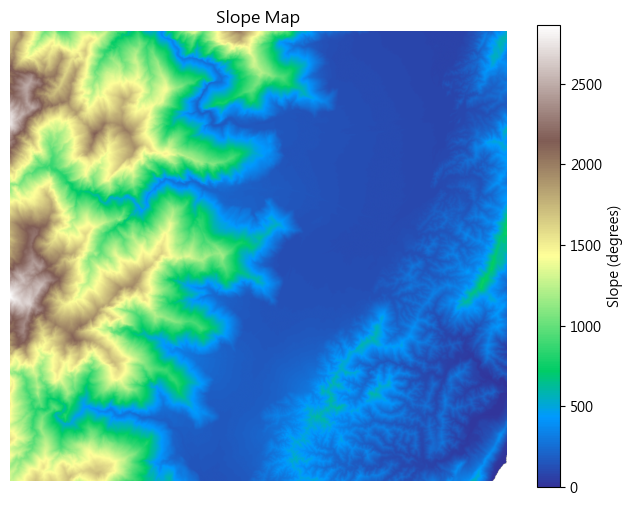

In [11]:
# [10] Load slope raster, or calculate from DEM, then display slope map
import matplotlib.pyplot as plt
import numpy as np
from rasterio.enums import Resampling

def calculate_slope_degrees(dem, profile):
    """
    Calculate slope in degrees from DEM.
    Assumes DEM is in a projected CRS with meter units.
    """
    transform = profile["transform"]
    xres = abs(transform.a)
    yres = abs(transform.e)

    dem = dem.astype(np.float32)
    dz_dy, dz_dx = np.gradient(dem, yres, xres)

    slope_rad = np.arctan(np.sqrt(dz_dx**2 + dz_dy**2))
    slope_deg = np.degrees(slope_rad)

    return slope_deg.astype(np.float32)

try:
    # Try loading existing slope raster
    slope, slope_profile, slope_path = read_single_band_tif(SLOPE_FILE)
    print(f"✅ Slope raster loaded: {slope_path}")

    if slope.shape != sar_water.shape:
        print(f"Slope shape {slope.shape} differs from SAR shape {sar_water.shape}; reprojecting to SAR grid.")
        slope = reproject_to_match(
            slope.astype(np.float32),
            slope_profile,
            sar_profile,
            resampling=Resampling.bilinear
        )

    slope_available = True

except Exception as e:
    print(f"⚠️ 無法載入 slope raster：{e}")
    print("嘗試由 DEM 計算 slope...")

    try:
        dem, dem_profile, dem_path = read_single_band_tif(DEM_FILE)
        print(f"✅ DEM loaded: {dem_path}")

        slope = calculate_slope_degrees(dem, dem_profile)
        slope_profile = dem_profile.copy()

        if slope.shape != sar_water.shape:
            print(f"Slope shape {slope.shape} differs from SAR shape {sar_water.shape}; reprojecting to SAR grid.")
            slope = reproject_to_match(
                slope.astype(np.float32),
                slope_profile,
                sar_profile,
                resampling=Resampling.bilinear
            )

        slope_available = True
        print("✅ Slope calculated from DEM.")

    except Exception as e2:
        print(f"⚠️ 無法由 DEM 計算 slope：{e2}")
        print("建立 NaN slope placeholder。正式繳交前請放入 slope_degrees.tif 或確認 DEM_FILE 路徑。")

        slope = np.full_like(sar_db, np.nan, dtype=np.float32)
        slope_available = False

print(f"Slope available: {slope_available}")

if slope_available:
    print(f"Slope range: {np.nanmin(slope):.2f}° to {np.nanmax(slope):.2f}°")

    plt.figure(figsize=(8, 6))
    plt.imshow(slope, cmap="terrain")
    plt.colorbar(label="Slope (degrees)")
    plt.title("Slope Map")
    plt.axis("off")
    plt.show()

In [15]:
# [11] Apply topographic filter and quantify removed false positives
flood_before_topo = (fusion >= 1).astype(np.uint8)
if slope_available:
    topo_false_positive = ((flood_before_topo == 1) & (slope > SLOPE_THRESHOLD)).astype(np.uint8)
else:
    topo_false_positive = np.zeros_like(flood_before_topo, dtype=np.uint8)

fusion_topo = fusion.copy()
fusion_topo[topo_false_positive == 1] = 0
removed_pixels = int(np.sum(topo_false_positive))
removed_area_km2 = removed_pixels * pixel_area_km2
print(f"Topographic filter removed {removed_pixels:,} pixels ({removed_area_km2:.3f} km²) of potential false positives.")

slope_bins = {
    "25–35°": (slope > 25) & (slope <= 35) & (topo_false_positive == 1),
    "35–45°": (slope > 35) & (slope <= 45) & (topo_false_positive == 1),
    ">45°": (slope > 45) & (topo_false_positive == 1),
}
slope_fp_table = pd.DataFrame([{"slope_class":k, "removed_pixels":int(np.sum(v)), "removed_area_km2":int(np.sum(v))*pixel_area_km2} for k,v in slope_bins.items()])
display(slope_fp_table)
slope_fp_table.to_csv(OUTPUT_DIR / "task3_topographic_false_positive_table.csv", index=False)
save_geotiff(OUTPUT_DIR / "fusion_confidence_map_topo_corrected.tif", fusion_topo, sar_profile, dtype="uint8", nodata=0)

Topographic filter removed 221,634 pixels (22.163 km²) of potential false positives.


,slope_class,removed_pixels,removed_area_km2
0,25–35°,130,0.0130
1,35–45°,148,0.0148
2,>45°,221356,22.1356


WindowsPath('output/fusion_confidence_map_topo_corrected.tif')

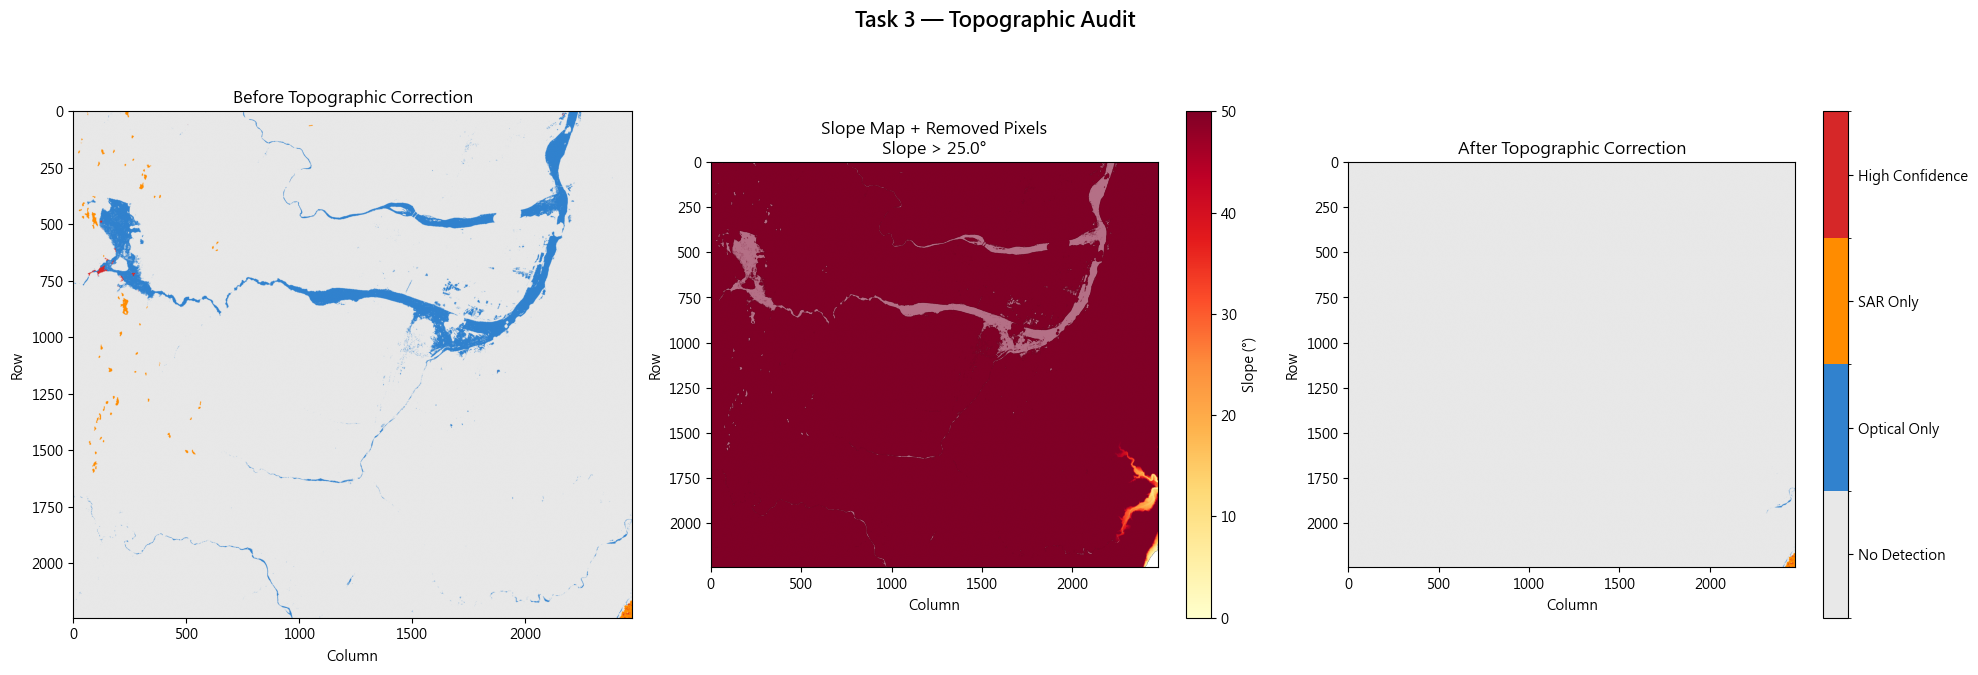

In [16]:
# [12] Task 3 deliverable: before/after maps and slope map
fig, axes = plt.subplots(1,3,figsize=(20,7))
axes[0].imshow(fusion, cmap=cmap_fusion, norm=norm_fusion)
axes[0].set_title("Before Topographic Correction")

if slope_available:
    im1 = axes[1].imshow(slope, cmap="YlOrRd", vmin=0, vmax=50)
    axes[1].imshow(np.ma.masked_where(topo_false_positive==0, topo_false_positive), cmap="Blues", alpha=0.45)
    axes[1].set_title(f"Slope Map + Removed Pixels\nSlope > {SLOPE_THRESHOLD}°")
    plt.colorbar(im1, ax=axes[1], shrink=0.8, label="Slope (°)")
else:
    axes[1].text(0.5, 0.5, "No slope raster available", ha="center", va="center", transform=axes[1].transAxes, fontsize=13)
    axes[1].set_title("Slope Map Unavailable")

im2 = axes[2].imshow(fusion_topo, cmap=cmap_fusion, norm=norm_fusion)
axes[2].set_title("After Topographic Correction")
cbar = plt.colorbar(im2, ax=axes[2], ticks=[0,1,2,3], shrink=0.8)
cbar.ax.set_yticklabels(["No Detection", "Optical Only", "SAR Only", "High Confidence"])

for ax in axes:
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")

plt.suptitle("Task 3 — Topographic Audit", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "task3_topographic_audit.png", dpi=150, bbox_inches="tight")
plt.show()

### DEM 適用性討論

在花蓮一般淹水案例中，如果研究區主要位於穩定平原或河道附近，Week 4 的 DEM slope 可以用來做地形校正，因為地形在災前與災後不會出現像崩塌堰塞湖那樣劇烈的高度改變。若研究區包含大量崩塌、土石流堆積或新形成堰塞湖，舊 DEM 可能不再代表災後地形，這時候不適合嚴格用 slope > 25° 直接刪除水體。若 DEM 不適用，我會優先改用 **morphological opening（形態學開運算）**、**connected component filtering（連通區塊過濾）**，再搭配人工檢查或災後 UAV / LiDAR / stereo imagery 更新地形資料。

## Task 4：AI Strategic Briefing + ARIA v7.0 Report

這一段把前面算出的重點指標整理成 LLM 可以理解的摘要，並產生 emergency management advisor（災害管理顧問）角度的簡報。正式繳交時，請把你實際貼給 LLM 的 prompt 與 LLM 回答完整保留在 notebook 裡。

In [17]:
# [13] Prepare metrics for AI strategic briefing
fusion_topo_table = area_table_from_classes(fusion_topo, fusion_labels, pixel_area_km2)
metrics = {
    "high_confidence_flood_area_km2": float(fusion_topo_table.loc[fusion_topo_table["class_code"] == 3, "area_km2"].iloc[0]),
    "sar_only_cloudy_flood_area_km2": float(fusion_topo_table.loc[fusion_topo_table["class_code"] == 2, "area_km2"].iloc[0]),
    "false_positives_removed_km2": float(removed_area_km2),
    "cloud_cover_percentage": float(cloud_cover_pct),
    "sar_threshold_db": SAR_THRESHOLD,
    "ndwi_threshold": NDWI_THRESHOLD,
    "total_detected_flood_area_km2": float(np.sum(fusion_topo >= 1) * pixel_area_km2),
}
print(json.dumps(metrics, indent=2, ensure_ascii=False))
with open(OUTPUT_DIR / "task4_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

{
  "high_confidence_flood_area_km2": 0.028800000000000003,
  "sar_only_cloudy_flood_area_km2": 0.2242,
  "false_positives_removed_km2": 22.1634,
  "cloud_cover_percentage": 28.400426659663893,
  "sar_threshold_db": -18.0,
  "ndwi_threshold": 0.3,
  "total_detected_flood_area_km2": 0.3594
}


In [18]:
# [14] Exact LLM prompt
llm_prompt = f"""
You are an emergency management advisor for Hualien County during Typhoon Fung-wong.

Based on these ARIA v7.0 sensor fusion results, generate a strategic briefing that covers:
1. Which areas require immediate evacuation?
2. How should resources be allocated between high-confidence and SAR-only zones?
3. What are the limitations of the current assessment?
4. What additional data would improve confidence?

Key metrics:
- High confidence flood area: {metrics['high_confidence_flood_area_km2']:.3f} km²
- SAR-only (cloudy) flood area: {metrics['sar_only_cloudy_flood_area_km2']:.3f} km²
- False positives removed by topographic filter: {metrics['false_positives_removed_km2']:.3f} km²
- Cloud cover percentage: {metrics['cloud_cover_percentage']:.1f}%
- SAR threshold: {metrics['sar_threshold_db']} dB. This threshold was selected based on the expected low VV backscatter of water; adjust if local water is rough or turbid.
- NDWI threshold: {metrics['ndwi_threshold']}. Clear water often uses about 0.3, while turbid water may require about 0.0.
- Total detected flood area after topographic filtering: {metrics['total_detected_flood_area_km2']:.3f} km²
""".strip()
print(llm_prompt)
with open(OUTPUT_DIR / "task4_llm_prompt.txt", "w", encoding="utf-8") as f:
    f.write(llm_prompt)

You are an emergency management advisor for Hualien County during Typhoon Fung-wong.

Based on these ARIA v7.0 sensor fusion results, generate a strategic briefing that covers:
1. Which areas require immediate evacuation?
2. How should resources be allocated between high-confidence and SAR-only zones?
3. What are the limitations of the current assessment?
4. What additional data would improve confidence?

Key metrics:
- High confidence flood area: 0.029 km²
- SAR-only (cloudy) flood area: 0.224 km²
- False positives removed by topographic filter: 22.163 km²
- Cloud cover percentage: 28.4%
- SAR threshold: -18.0 dB. This threshold was selected based on the expected low VV backscatter of water; adjust if local water is rough or turbid.
- NDWI threshold: 0.3. Clear water often uses about 0.3, while turbid water may require about 0.0.
- Total detected flood area after topographic filtering: 0.359 km²


### AI Strategic Briefing — Prompt and Response

**Exact prompt used:** 請執行上一格產生的 `llm_prompt`，並把實際使用的 prompt 貼在這裡。若你使用上一格原封不動的 prompt，就可以直接註明「Same as Cell [14] generated prompt」。

**LLM response:** 請把 LLM 的完整回覆貼在這裡。回覆內容應該包含立即撤離區域、資源配置策略、評估限制，以及可以提升信心的額外資料。

**My reflection:** LLM 的回答在「把高信心區視為優先處置區、把 SAR-only 雲遮區列為巡查與預警區」這點合理，因為它符合融合圖的證據強度。需要小心的是，LLM 可能會把像素分類直接解讀成行政區或精確災情，這超出本分析能支持的範圍。這份結果應該被當成災害初期的空間篩選工具，而不是最終現地判定。後續若能加入現地回報、更新 DEM、河川水位站與更高解析度影像，決策信心會更高。

In [19]:
# [15] ARIA v7.0 vs. v6.0 comparison table
w9_optical_area_km2 = float(os.getenv("W9_OPTICAL_AREA_KM2", np.sum(ndwi_mask == 1) * pixel_area_km2))
w10_fused_area_km2 = metrics["total_detected_flood_area_km2"]
cloud_area_km2 = np.sum(cloud_mask == 1) * pixel_area_km2
comparison_table = pd.DataFrame([
    {"Metric":"Total detected flood area", "W9 (Optical Only)":f"{w9_optical_area_km2:.3f} km²", "W10 (Fused)":f"{w10_fused_area_km2:.3f} km²", "Improvement":f"{w10_fused_area_km2-w9_optical_area_km2:+.3f} km²"},
    {"Metric":"Cloud-covered area analyzed", "W9 (Optical Only)":"0.000 km²", "W10 (Fused)":f"{cloud_area_km2:.3f} km²", "Improvement":"SAR enables cloudy-area analysis"},
    {"Metric":"False positives removed by topographic filter", "W9 (Optical Only)":"N/A", "W10 (Fused)":f"{removed_area_km2:.3f} km²", "Improvement":"terrain-aware audit"},
    {"Metric":"Confidence levels", "W9 (Optical Only)":"binary / optical confidence", "W10 (Fused)":"4-class confidence map", "Improvement":"finer granularity"},
])
display(comparison_table)
comparison_table.to_csv(OUTPUT_DIR / "task4_w9_w10_comparison.csv", index=False)

,Metric,W9 (Optical Only),W10 (Fused),Improvement
0,Total detected flood area,24.817 km²,0.359 km²,-24.457 km²
1,Cloud-covered area analyzed,0.000 km²,157.465 km²,SAR enables cloudy-area analysis
2,False positives removed by topographic filter,N/A,22.163 km²,terrain-aware audit
3,Confidence levels,binary / optical confidence,4-class confidence map,finer granularity


## ARIA v7.0 vs. v6.0 Comparison

W9 的 optical-only 方法主要依賴 **NDWI（Normalized Difference Water Index）** 與雲遮罩，因此在颱風期間會被雲遮蔽限制。W10 的 fused 方法把 **SAR（Synthetic Aperture Radar）** 加入後，可以在 cloudy area（雲遮區）補上水體偵測能力，並用四分類信心圖把結果分成 High Confidence、SAR Only、Optical Only 與 No Detection。這個改進讓結果更適合災害早期預警，因為它可以標示「哪些地方有雙重證據、哪些地方只有 SAR 但仍值得優先巡查」。

In [20]:
# [16] Final sanity checks and output inventory
checks = [
    ("SAR water area is not entire scene", np.mean(sar_water) < 0.8),
    ("Median filter was applied before thresholding", sar_filtered.shape == sar_db.shape),
    ("Fusion classes are within 0–3", set(np.unique(fusion)).issubset({0,1,2,3})),
    ("Topographic correction does not increase flood area", np.sum(fusion_topo >= 1) <= np.sum(fusion >= 1)),
    ("Pixel area is positive", pixel_area_km2 > 0),
]
check_table = pd.DataFrame(checks, columns=["check", "passed"])
display(check_table)

print("\nOutput files:")
for p in sorted(OUTPUT_DIR.glob("*")):
    print(f"- {p}")

if not check_table["passed"].all():
    print("\n⚠️ Some sanity checks failed. Inspect figures and thresholds before submission.")
else:
    print("\n✅ All basic sanity checks passed.")

,check,passed
0,SAR water area is not entire scene,True
1,Median filter was applied before thresholding,True
2,Fusion classes are within 0–3,True
3,Topographic correction does not increase flood...,True
4,Pixel area is positive,True



Output files:
- output\fusion_confidence_map.npy
- output\fusion_confidence_map.tif
- output\fusion_confidence_map_topo_corrected.tif
- output\sar_water_mask.npy
- output\sar_water_mask.tif
- output\task1_raw_sar.png
- output\task1_sar_area_table.csv
- output\task1_sar_flood_detection_2x2.png
- output\task1_speckle_filter_before_after.png
- output\task2_fusion_area_table.csv
- output\task2_fusion_confidence_map.png
- output\task3_topographic_audit.png
- output\task3_topographic_false_positive_table.csv
- output\task4_llm_prompt.txt
- output\task4_metrics.json
- output\task4_w9_w10_comparison.csv

✅ All basic sanity checks passed.


## Submission Checklist

- [ ] SAR GeoTIFF 已成功讀取，並完成 raw / filtered / mask / overlay 2×2 圖。  
- [ ] SAR threshold、median filter、morphological cleanup 與 connected component filtering 已明確記錄。  
- [ ] W9 NDWI water mask 與 SCL cloud mask 已載入，且 shape 與 SAR mask 一致。  
- [ ] 四分類 confidence map 已產生，並輸出每一類面積統計。  
- [ ] DEM slope 已用於地形審計，或已清楚說明 DEM 不適用時的替代清理策略。  
- [ ] AI strategic briefing 已包含 exact prompt、response 與自己的 reflection。  
- [ ] W9 vs. W10 comparison table 已填入真實數值或明確註記估算來源。  
- [ ] 所有輸出已存到 `output/`，並完成 sanity checks。